# Tesla EV deliveries: ML pipeline (2015-2025)

Supervised regression on the Tesla sales CSV (target: deliveries), with a short annual forecast at the
end. One sklearn pipeline: preprocessing, EDA, features, models, tuning, forecasting.

In [1]:
import os, warnings
warnings.filterwarnings("ignore")        # mostly statsmodels convergence chatter
os.environ["PYTHONWARNINGS"] = "ignore"  # keep joblib worker processes quiet too

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
SEED = 42
np.random.seed(SEED)
RF_PARAMS = dict(n_estimators=300, random_state=SEED, n_jobs=-1)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

def rmse(y, p):
    return mean_squared_error(y, p) ** 0.5

def score(name, y, p):
    return {"Model": name, "R2": r2_score(y, p), "RMSE": rmse(y, p), "MAE": mean_absolute_error(y, p)}

## 1. Load and clean

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 337.3 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


Types are fine. Price looks uniform (50k-120k); battery is 5 distinct values, effectively a category stored as int.

In [5]:
print("missing values:", df.isna().sum().sum())
print("duplicate rows :", df.duplicated().sum())

# the row count is suspiciously round - is this a full grid?
print("11 * 12 * 4 * 5 =", 11 * 12 * 4 * 5)
print("unique (year,month,region,model) combos:",
      df.groupby(["Year", "Month", "Region", "Model"]).ngroups)

missing values: 0
duplicate rows : 0
11 * 12 * 4 * 5 = 2640
unique (year,month,region,model) combos: 2640


Nothing missing or duplicated. 2,640 rows = 11 × 12 × 4 × 5, one per combination - a generated full grid, not a
real export (the Cybertruck even has 2015 "sales"). Nothing to clean.

In [6]:
# light type fixes: a real date for the time-series part, categories for the labels
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2) + "-01")
for c in ["Region", "Model", "Source_Type"]:
    df[c] = df[c].astype("category")
df = df.sort_values("Date").reset_index(drop=True)

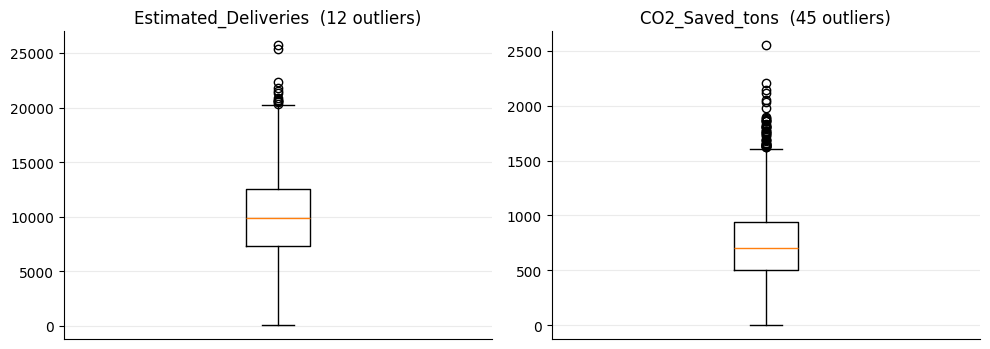

In [7]:
# outliers: ~0.5% of deliveries and ~1.7% of CO2 fall past the 1.5*IQR whiskers, all on the high
# side. Not errors though - deliveries are bell-shaped and CO2 is a product (long right tail), so
# I'm keeping every row rather than capping a legitimate tail.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a, col in zip(ax, ["Estimated_Deliveries", "CO2_Saved_tons"]):
    q1, q3 = df[col].quantile([.25, .75]); iqr = q3 - q1
    n = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    a.boxplot(df[col]); a.set_title(f"{col}  ({n} outliers)"); a.set_xticks([])
plt.tight_layout(); plt.show()

In [8]:
# two columns look mechanically tied to the target - check them before trusting any model
print("rows with production < deliveries:", (df["Production_Units"] < df["Estimated_Deliveries"]).sum())
r = df["Production_Units"] / df["Estimated_Deliveries"]
print("production / deliveries ratio: {:.3f} to {:.3f}".format(r.min(), r.max()))

k = df["CO2_Saved_tons"] / (df["Estimated_Deliveries"] * df["Range_km"])
print("CO2 / (deliveries * range):   mean {:.5f}, std {:.2e}".format(k.mean(), k.std()))

rows with production < deliveries: 0
production / deliveries ratio: 1.000 to 1.150
CO2 / (deliveries * range):   mean 0.00015, std 4.72e-09


CO2_Saved is exactly 0.00015 × deliveries × range (the ratio has near-zero spread) - target leakage, a model
just back-solves deliveries from it. Production is deliveries × a 0-15% buffer, also dropped. I keep CO2 for the
first pass to show its effect, then drop it.

## 2. EDA

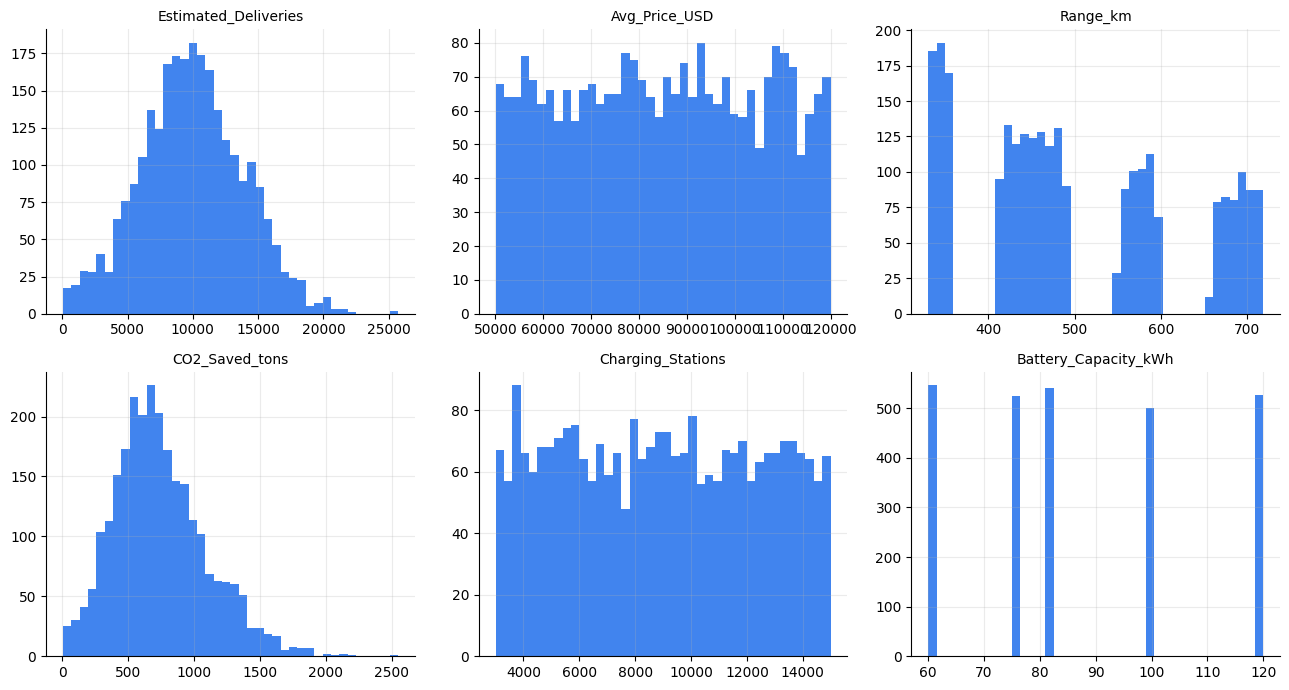

In [9]:
cols = ["Estimated_Deliveries", "Avg_Price_USD", "Range_km",
        "CO2_Saved_tons", "Charging_Stations", "Battery_Capacity_kWh"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), cols):
    ax.hist(df[c], bins=40, color="#1f6feb", alpha=0.85); ax.set_title(c, fontsize=10)
plt.tight_layout(); plt.show()

Price and charging stations are flat-topped (uniform); deliveries is a clean bell; only CO2 is skewed. Mostly independent random numbers.

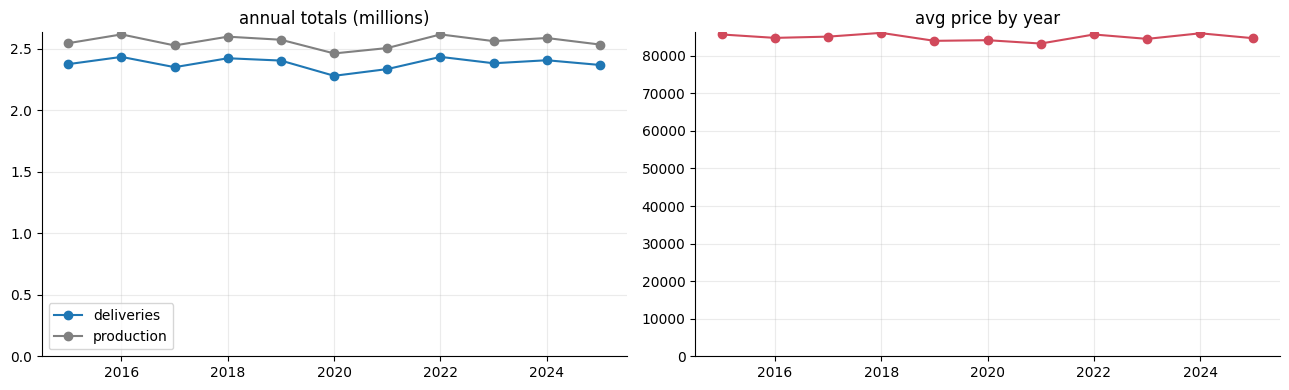

In [10]:
by_year = df.groupby("Year").agg(deliveries=("Estimated_Deliveries", "sum"),
                                 production=("Production_Units", "sum"),
                                 price=("Avg_Price_USD", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(by_year.index, by_year["deliveries"]/1e6, "-o", label="deliveries")
ax[0].plot(by_year.index, by_year["production"]/1e6, "-o", color="grey", label="production")
ax[0].set_title("annual totals (millions)"); ax[0].set_ylim(0, None); ax[0].legend()
ax[1].plot(by_year.index, by_year["price"], "-o", color="#d1495b")
ax[1].set_title("avg price by year"); ax[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

Flat. Real Tesla grew from ~50k (2015) to ~1.8M (2023); here every year sits near 2.38M - volume was drawn independent of the year.

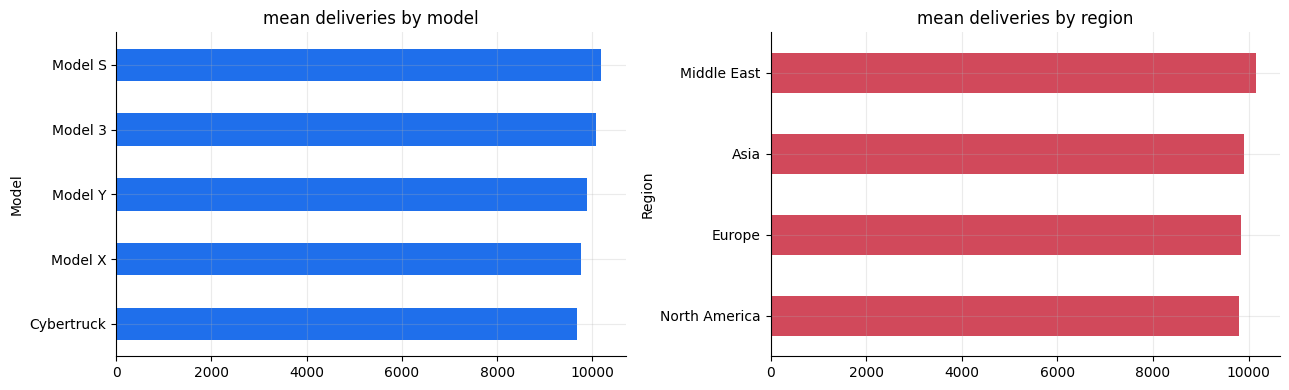

In [11]:
# deliveries barely move across models or regions - no segment structure to learn
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("Model", observed=True)["Estimated_Deliveries"].mean().sort_values().plot.barh(ax=ax[0], color="#1f6feb")
df.groupby("Region", observed=True)["Estimated_Deliveries"].mean().sort_values().plot.barh(ax=ax[1], color="#d1495b")
ax[0].set_title("mean deliveries by model"); ax[1].set_title("mean deliveries by region")
plt.tight_layout(); plt.show()

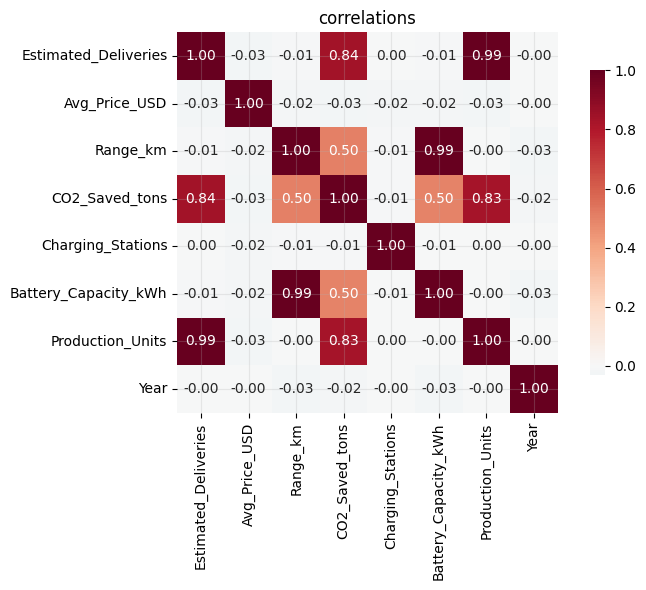

In [12]:
corr = df[cols + ["Production_Units", "Year"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("correlations"); plt.tight_layout(); plt.show()

Near zero everywhere except the two mechanical links (deliveries-production-CO2, battery-range). Nothing exogenous tracks deliveries.

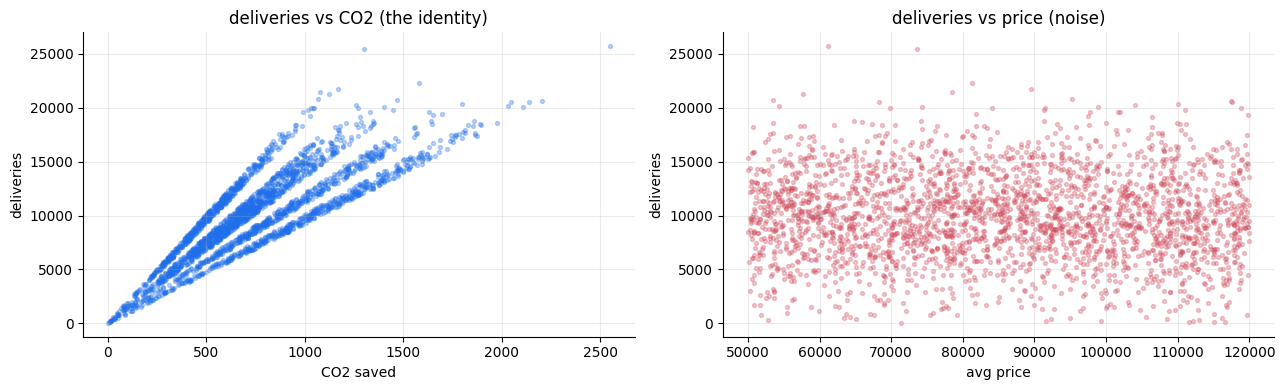

In [13]:
# left: the CO2 identity (a fan, spread out by range). right: price vs deliveries is pure noise.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(df["CO2_Saved_tons"], df["Estimated_Deliveries"], s=8, alpha=.3, color="#1f6feb")
ax[0].set(xlabel="CO2 saved", ylabel="deliveries", title="deliveries vs CO2 (the identity)")
ax[1].scatter(df["Avg_Price_USD"], df["Estimated_Deliveries"], s=8, alpha=.3, color="#d1495b")
ax[1].set(xlabel="avg price", ylabel="deliveries", title="deliveries vs price (noise)")
plt.tight_layout(); plt.show()

## 3. Feature engineering

A few standard features: price per kWh, range per kWh, model age (year minus launch year) and a
per-car CO2 figure. They can't add signal the data doesn't have, but they're worth building and
checking.

In [14]:
launch = {"Model S": 2012, "Model X": 2015, "Model 3": 2017, "Model Y": 2020, "Cybertruck": 2023}
df["price_per_kwh"]   = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["range_per_kwh"]   = df["Range_km"] / df["Battery_Capacity_kWh"]
df["model_age"]       = (df["Year"] - df["Model"].astype(str).map(launch)).clip(lower=0)
df["co2_per_vehicle"] = df["CO2_Saved_tons"] / df["Estimated_Deliveries"]
df[["Model", "Year", "model_age", "price_per_kwh", "range_per_kwh"]].head()

,Model,Year,model_age,price_per_kwh,range_per_kwh
0,Model Y,2015,0,919.718833,5.666667
1,Model 3,2015,0,892.894000,5.880000
2,Cybertruck,2015,0,1714.809667,5.600000
3,Cybertruck,2015,0,1280.028293,5.597561
4,Model 3,2015,0,1073.033293,5.560976


In [15]:
# how much does anything actually correlate with deliveries?
feats = ["Year", "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km", "Charging_Stations",
         "price_per_kwh", "range_per_kwh", "model_age", "co2_per_vehicle", "CO2_Saved_tons"]
df[feats].corrwith(df["Estimated_Deliveries"]).abs().sort_values(ascending=False).round(3)

CO2_Saved_tons          0.837
Avg_Price_USD           0.028
model_age               0.020
price_per_kwh           0.018
range_per_kwh           0.014
Battery_Capacity_kWh    0.008
co2_per_vehicle         0.007
Range_km                0.007
Year                    0.003
Charging_Stations       0.001
dtype: float64

Only CO2 (the leak) clears the noise floor; everything else sits under 0.04. The engineered features stop here.

## 4. Regression

Target: deliveries. Predictors: year, model, region, price, battery, range, CO2 (Production dropped as
leakage). One pipeline - one-hot for Model/Region, standardise the numerics (Ridge/Lasso need it) - across
linear, Ridge, Lasso, RF and GBM, scored on a held-out split plus 5-fold CV.

In [16]:
num = ["Year", "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons"]
cat = ["Model", "Region"]
X, y = df[num + cat], df["Estimated_Deliveries"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

prep = ColumnTransformer([("num", StandardScaler(), num),
                          ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])
models = {
    "Linear":            LinearRegression(),
    "Ridge":             Ridge(alpha=10.0),
    "Lasso":             Lasso(alpha=10.0),
    "Random Forest":     RandomForestRegressor(**RF_PARAMS),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}
kf = KFold(5, shuffle=True, random_state=SEED)
rows = []
for name, est in models.items():
    pipe = Pipeline([("prep", prep), ("model", est)]).fit(X_train, y_train)
    rec = score(name, y_test, pipe.predict(X_test))
    rec["CV_R2"] = cross_val_score(pipe, X, y, cv=kf, scoring="r2").mean()
    rows.append(rec)
pd.DataFrame(rows).set_index("Model").sort_values("RMSE").round(3)

,R2,RMSE,MAE,CV_R2
Model,,,,
Random Forest,0.998,160.091,102.910,0.997
Gradient Boosting,0.997,223.437,161.150,0.996
Lasso,0.942,931.355,667.249,0.943
Linear,0.942,935.064,668.903,0.942
Ridge,0.942,936.055,670.695,0.942


Linear caps ~0.94, trees ~0.998. The gap is the CO2/range division - a linear model can't divide two features, trees split their way to it. What the forest used:

In [17]:
rf = Pipeline([("prep", prep), ("model", RandomForestRegressor(**RF_PARAMS))])
rf.fit(X_train, y_train)
names = num + list(rf.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat))
pd.Series(rf.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).round(3).head(7)

CO2_Saved_tons          0.813
Range_km                0.159
Battery_Capacity_kWh    0.026
Avg_Price_USD           0.001
Year                    0.001
Model_Model 3           0.000
Region_Asia             0.000
dtype: float64

~97% of the forest is CO2 + range; price, year, model, region ignored. Drop CO2 and refit on the exogenous features only:

In [18]:
num_h = ["Year", "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km"]
Xh = df[num_h + cat]
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, y, test_size=0.2, random_state=SEED)
prep_h = ColumnTransformer([("num", StandardScaler(), num_h),
                            ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])
rows = []
for name, est in models.items():
    pipe = Pipeline([("prep", prep_h), ("model", est)]).fit(Xh_tr, yh_tr)
    rows.append(score(name, yh_te, pipe.predict(Xh_te)))
pd.DataFrame(rows).set_index("Model").sort_values("RMSE").round(3)

,R2,RMSE,MAE
Model,,,
Lasso,-0.006,3881.986,3069.345
Ridge,-0.010,3889.862,3075.512
Linear,-0.012,3893.531,3077.886
Gradient Boosting,-0.020,3909.235,3114.590
Random Forest,-0.074,4011.302,3186.647


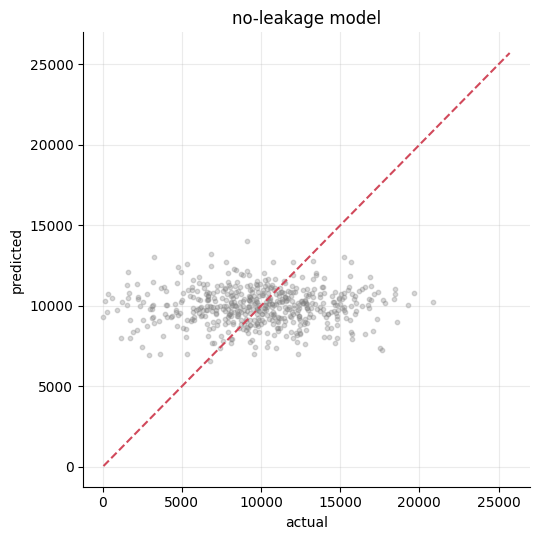

In [19]:
# no-CO2 model: predictions barely move off the mean regardless of the true value
best_h = Pipeline([("prep", prep_h), ("model", RandomForestRegressor(**RF_PARAMS))])
best_h.fit(Xh_tr, yh_tr)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(yh_te, best_h.predict(Xh_te), s=10, alpha=.3, color="grey")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--", color="#d1495b")
plt.xlabel("actual"); plt.ylabel("predicted"); plt.title("no-leakage model")
plt.tight_layout(); plt.show()

Without CO2 every model is R²≈0 (RF slightly negative), MAE ~3,100 on a ~9,900 mean - no better than guessing the average.

### Bias-variance, over- vs under-fitting

Train vs test R² for a linear model and the forest, with CO2 and without. Train-test gap = variance; how far train sits below 1 = bias.

In [20]:
def train_test_r2(prep_, Xtr, Xte, ytr, yte, est):
    p = Pipeline([("prep", prep_), ("model", est)]).fit(Xtr, ytr)
    return r2_score(ytr, p.predict(Xtr)), r2_score(yte, p.predict(Xte))

rows = []
for label, est in [("Linear", LinearRegression()),
                   ("Random Forest", RandomForestRegressor(**RF_PARAMS))]:
    tr_c, te_c = train_test_r2(prep,   X_train, X_test, y_train, y_test, est)   # with CO2
    tr_h, te_h = train_test_r2(prep_h, Xh_tr,   Xh_te,  yh_tr,   yh_te,  est)   # no CO2
    rows.append({"model": label, "train R2 (CO2)": tr_c, "test R2 (CO2)": te_c,
                 "train R2 (no CO2)": tr_h, "test R2 (no CO2)": te_h})
pd.DataFrame(rows).set_index("model").round(3)

,train R2 (CO2),test R2 (CO2),train R2 (no CO2),test R2 (no CO2)
model,,,,
Linear,0.944,0.942,0.006,-0.012
Random Forest,0.999,0.998,0.851,-0.074


Linear+CO2 is ~0.94 both sides - low variance, but capped short of the forest's 0.998 (bias: can't do CO2/range).
Without CO2 the forest goes train 0.85 / test below 0 - pure variance, memorising noise; linear stays ≈0 both -
underfit, nothing to fit.

## 5. Hyperparameter tuning

Tune the RF (the best model) with GridSearchCV over depth, tree count, leaf size and feature
fraction. It's already pinned to the identity, so I don't expect much.

In [21]:
grid = GridSearchCV(
    Pipeline([("prep", prep), ("model", RandomForestRegressor(random_state=SEED))]),
    {"model__n_estimators": [200, 400], "model__max_depth": [None, 12, 20],
     "model__min_samples_leaf": [1, 2], "model__max_features": ["sqrt", 1.0]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1).fit(X_train, y_train)
print("best params: ", grid.best_params_)
print("best CV RMSE:", round(-grid.best_score_, 1))

# tuned vs default on the same test set
default_rf = Pipeline([("prep", prep), ("model", RandomForestRegressor(**RF_PARAMS))])
default_rf.fit(X_train, y_train)
pd.DataFrame([score("RF default", y_test, default_rf.predict(X_test)),
              score("RF tuned",   y_test, grid.predict(X_test))]).set_index("Model").round(3)

best params:  {'model__max_depth': 12, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
best CV RMSE: 271.9


,R2,RMSE,MAE
Model,,,
RF default,0.998,160.091,102.910
RF tuned,0.998,160.100,103.874


RMSE barely moves (~160 either way, tuned is a hair worse). You can't tune past an exact identity.

## 6. Time-series forecast

First check the monthly series (132 points) for trend, seasonality, autocorrelation and stationarity - if
they're absent, Holt and ARIMA have nothing to grip. Then aggregate to annual, split chronologically, and
forecast. Only 11 yearly points.

### Structure check (monthly)

Monthly totals, four checks: rolling stats, trend/seasonal/residual decomposition, ADF, and lag-1/lag-12 autocorrelation.

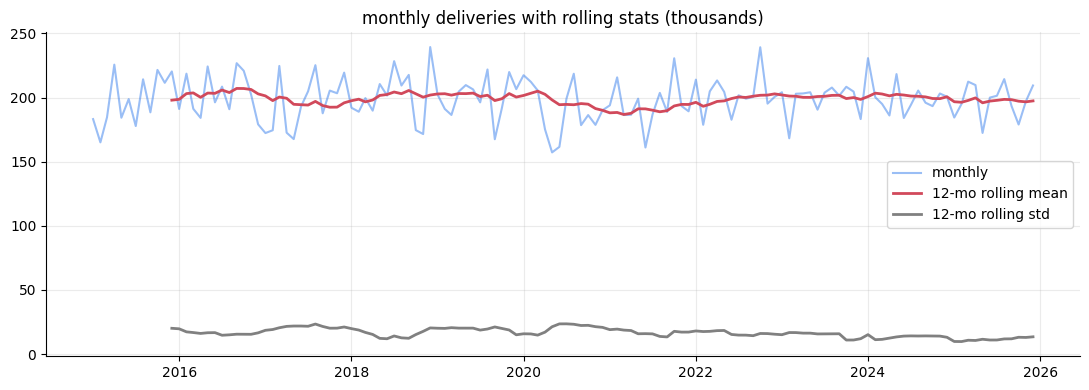

In [22]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().asfreq("MS")
roll_mean, roll_std = monthly.rolling(12).mean(), monthly.rolling(12).std()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly / 1e3, color="#1f6feb", alpha=.45, label="monthly")
ax.plot(roll_mean.index, roll_mean / 1e3, color="#d1495b", lw=2, label="12-mo rolling mean")
ax.plot(roll_std.index,  roll_std  / 1e3, color="grey",    lw=2, label="12-mo rolling std")
ax.set_title("monthly deliveries with rolling stats (thousands)"); ax.legend()
plt.tight_layout(); plt.show()

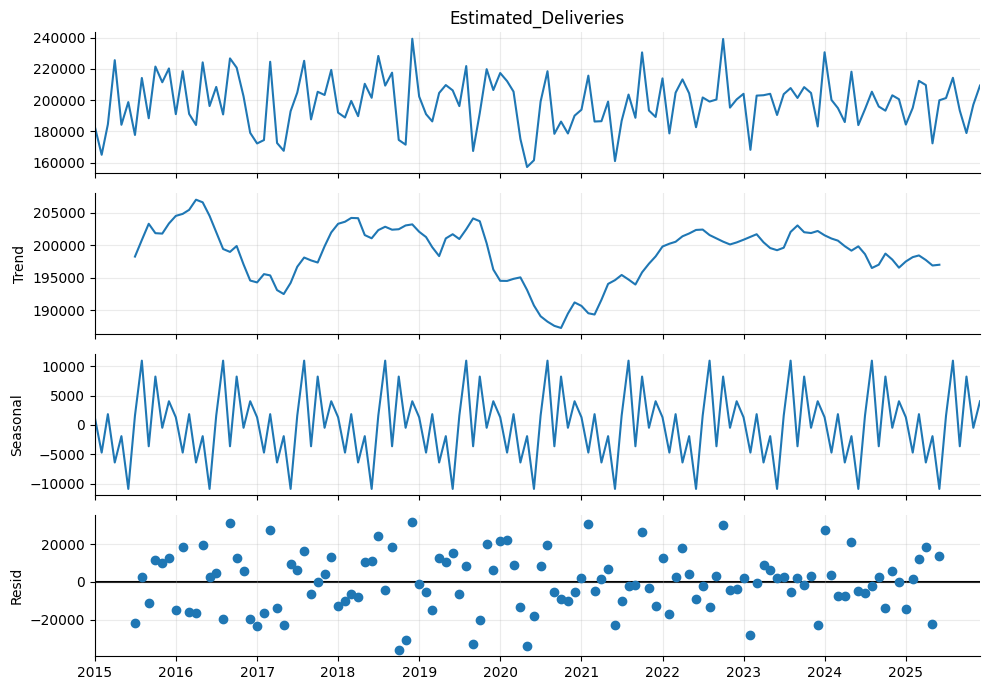

residual std / series std: 0.90  (share of the variation left as noise)


In [23]:
# additive trend / seasonal / residual split, period=12 to catch an annual cycle if one exists
dec = seasonal_decompose(monthly, model="additive", period=12)
dec.plot(); plt.gcf().set_size_inches(10, 7); plt.tight_layout(); plt.show()
print("residual std / series std: {:.2f}  (share of the variation left as noise)".format(
    dec.resid.std() / monthly.std()))

In [24]:
stat, pval, *_ = adfuller(monthly)
print("ADF: statistic {:.2f}, p-value {:.4f}  ->  {}".format(
    stat, pval, "stationary" if pval < 0.05 else "unit root (non-stationary)"))
for L in (1, 12):
    print("lag-{:>2} autocorrelation: {:+.3f}".format(L, monthly.autocorr(L)))

ADF: statistic -8.88, p-value 0.0000  ->  stationary
lag- 1 autocorrelation: +0.015
lag-12 autocorrelation: +0.022


Rolling mean and std are flat - stationary, and ADF agrees (p<0.001). ~90% of the variance is residual; the
seasonal panel repeats but it's the artefact of 11 noisy years per month (lag-12 autocorr is +0.02, a real cycle
would be strongly positive), and lag-1 is +0.02 too. No trend, seasonality or memory - the annual mean is hard to beat.

mean 2,381,328, CV 2.0%


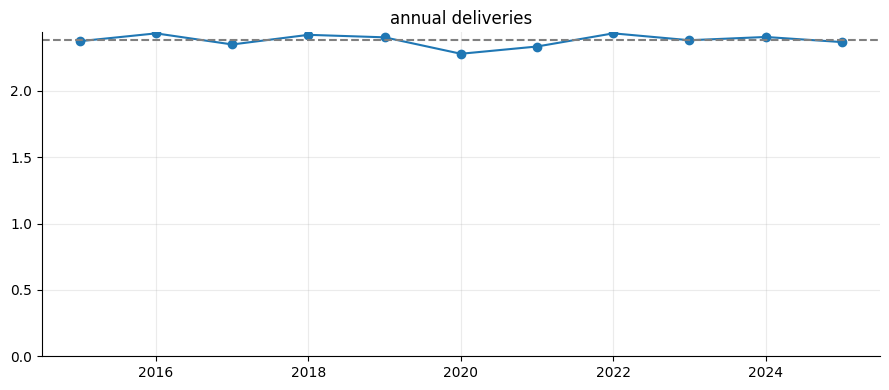

In [25]:
annual = df.groupby("Year")["Estimated_Deliveries"].sum()
annual.index = pd.to_datetime(annual.index.astype(str) + "-01-01")
annual = annual.asfreq("YS")
print("mean {:,.0f}, CV {:.1%}".format(annual.mean(), annual.std()/annual.mean()))

plt.figure(figsize=(9, 4))
plt.plot(annual.index.year, annual.values/1e6, "-o")
plt.axhline(annual.mean()/1e6, ls="--", color="grey")
plt.title("annual deliveries"); plt.ylim(0, None); plt.tight_layout(); plt.show()

In [26]:
train, test = annual[annual.index.year <= 2022], annual[annual.index.year >= 2023]

def ts_metrics(name, pred):
    pred, truth = np.asarray(pred, float), test.values.astype(float)
    return {"method": name, "MAE": mean_absolute_error(truth, pred),
            "RMSE": rmse(truth, pred), "MAPE%": np.mean(np.abs((truth-pred)/truth))*100}

rows = [ts_metrics("mean", [train.mean()]*len(test))]
rows.append(ts_metrics("linear trend", np.polyval(np.polyfit(train.index.year, train.values, 1), test.index.year)))
rows.append(ts_metrics("Holt", ExponentialSmoothing(train, trend="add").fit().forecast(len(test)).values))
for o in [(1, 0, 0), (1, 1, 1)]:
    rows.append(ts_metrics(f"ARIMA{o}", ARIMA(train, order=o).fit().forecast(len(test)).values))
pd.DataFrame(rows).set_index("method").sort_values("MAPE%").round(2)

,MAE,RMSE,MAPE%
method,,,
mean,13734.38,17094.40,0.57
Holt,14342.93,17311.57,0.60
"ARIMA(1, 0, 0)",15584.11,17422.28,0.65
linear trend,26703.61,30664.96,1.12
"ARIMA(1, 1, 1)",47746.35,50282.78,2.01


Mean wins; Holt and ARIMA(1,0,0) tie it; the trend-followers (linear, ARIMA(1,1,1)) do worse. On a flat series, modelling movement just fits noise.

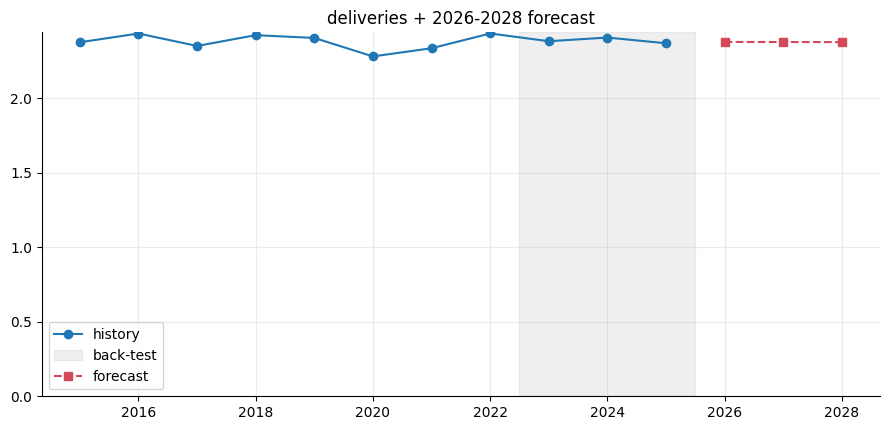

forecast (millions): [np.float64(2.38), np.float64(2.38), np.float64(2.38)]


In [27]:
fit = ExponentialSmoothing(annual, trend="add").fit()
future = [2026, 2027, 2028]
fc = fit.forecast(3)
plt.figure(figsize=(9, 4.4))
plt.plot(annual.index.year, annual.values/1e6, "-o", label="history")
plt.axvspan(2022.5, 2025.5, color="grey", alpha=.12, label="back-test")
plt.plot(future, fc.values/1e6, "--s", color="#d1495b", label="forecast")
plt.title("deliveries + 2026-2028 forecast"); plt.ylim(0, None); plt.legend()
plt.tight_layout(); plt.show()
print("forecast (millions):", [round(v/1e6, 2) for v in fc.values])

Forecast is flat ~2.38M. With 11 points and a series flat by construction (not because Tesla plateaued), it's the average carried forward, not a real projection.

## Takeaways

- Synthetic grid; the only real signal is the built-in CO2 = 0.00015 × deliveries × range (and production ≈ deliveries).
- With CO2 the RF hits R²≈0.998 - leakage; drop it and R²≈0, the market features don't predict deliveries.
- Flat annual series, so the forecast is just the mean (~2.38M); tuning can't beat an exact identity.